In [1]:
# Import & Load data (pastikan paket penting terpasang cek requirements.txt)

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder


# Load data yang sudah fitur tambahan dan label kelas sebelumnya
data_candidates = [
    Path('data') / 'master' / 'Master Data - fitur & label.xlsx',
    Path('..') / 'data' / 'master' / 'Master Data - fitur & label.xlsx',
    Path.cwd().parent / 'data' / 'master' / 'Master Data - fitur & label.xlsx',
]
path = next((p for p in data_candidates if p.exists()), data_candidates[0])
print('Using data file:', path.resolve())
df = pd.read_excel(path)

print(df.shape)
display(df.head())

# Pilih fitur dan target
target = "kelas_layanan"

feature_cols = [
    "kepadatan_penduduk",
    "rasio_apotek", "rasio_puskesmas_total", "rasio_klinik", "rasio_rsu_total",
    "dens_apotek",  "dens_puskesmas_total",  "dens_klinik",  "dens_rsu_total"
]

# cek kolom yang kepakai ada semua
missing = [c for c in [target, "kab_kota"] + feature_cols if c not in df.columns]
if missing:
    raise ValueError(f"Kolom ini tidak ada di dataframe: {missing}")

X = df[feature_cols]
y = df[target]

    # --- REGRESSION ANALYSIS (Target: skor_layanan) ---
    # Tambahkan analisis regresi sebelum klasifikasi
print("\n=== Regression Report (Target: skor_layanan) ===")
y_reg = df["skor_layanan"]
rf_reg = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_reg = cross_val_predict(rf_reg, X, y_reg, cv=kf)

mae = mean_absolute_error(y_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_reg, y_pred_reg))
r2 = r2_score(y_reg, y_pred_reg)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

# implementasi model random forest dengan cross-validation
model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced"
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred = cross_val_predict(model, X, y, cv=cv)

print("\n=== Classification Report (CV) ===")
print(classification_report(y, y_pred))

print("\n=== Confusion Matrix (CV) ===")
print(confusion_matrix(y, y_pred, labels=["Rendah", "Sedang", "Tinggi"]))


# Fit model ke seluruh data untuk mendapatkan feature importance
model.fit(X, y)
imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

print("\n=== Feature Importance ===")
display(imp)

# TOP/BOTTOM RASIO (5 TERENDAH & 5 TERTINGGI)
def top_bottom(df, daerah_col, metric_col, n=5):
    tmp = df[[daerah_col, metric_col]].sort_values(metric_col)
    bottom = tmp.head(n).reset_index(drop=True)
    top = tmp.tail(n).sort_values(metric_col, ascending=False).reset_index(drop=True)
    return bottom, top

daerah_col = "kab_kota"

rasio_metrics = [
    "rasio_apotek",
    "rasio_puskesmas_total",
    "rasio_klinik",
    "rasio_rsu_total"
]

for m in rasio_metrics:
    bottom, top = top_bottom(df, daerah_col, m, n=5)
    print(f"\n===== {m}: 5 TERENDAH =====")
    display(bottom)
    print(f"===== {m}: 5 TERTINGGI =====")
    display(top)


# ranking berdasarkan skor gabungan :
print("\n===== Skor Gabungan (skor_layanan): 5 TERENDAH =====")
display(df[[daerah_col, "skor_layanan", "kelas_layanan"]].sort_values("skor_layanan").head(5))

print("\n===== Skor Gabungan (skor_layanan): 5 TERTINGGI =====")
display(df[[daerah_col, "skor_layanan", "kelas_layanan"]].sort_values("skor_layanan", ascending=False).head(5))

# Simpan hasil feature importance
out_candidates = [
    Path('outputs') / 'feature_importance.csv',
    Path('..') / 'outputs' / 'feature_importance.csv',
    Path.cwd().parent / 'outputs' / 'feature_importance.csv',
]
out_imp_path = next((p for p in out_candidates if p.parent.exists()), out_candidates[0])
out_imp_path.parent.mkdir(parents=True, exist_ok=True)
imp.to_csv(out_imp_path)
print('Saved feature importance to:', out_imp_path.resolve())

# Read feature importance
imp_read_candidates = [
    Path('outputs') / 'feature_importance.csv',
    Path('..') / 'outputs' / 'feature_importance.csv',
    Path.cwd().parent / 'outputs' / 'feature_importance.csv',
]
imp_path = next((p for p in imp_read_candidates if p.exists()), imp_read_candidates[0])
imp = pd.read_csv(imp_path, header=None, index_col=0).squeeze('columns')
imp = imp.sort_values(ascending=False)
display(imp.head(7))

# Read rangking file 
rank_candidates = [
    Path('outputs') / 'tables' / 'ranking_top_bottom_2024.xlsx',
    Path('..') / 'outputs' / 'tables' / 'ranking_top_bottom_2024.xlsx',
    Path.cwd().parent / 'outputs' / 'tables' / 'ranking_top_bottom_2024.xlsx',
]
rank_path = next((p for p in rank_candidates if p.exists()), rank_candidates[0])
if rank_path.exists():
    xls = pd.ExcelFile(rank_path)
    print(xls.sheet_names)
else:
    print('Ranking file not found. Looked at:', [str(p.resolve()) for p in rank_candidates])

Using data file: C:\Users\femmy\OneDrive\Documents\6. Semester 6\tugas_akhir_machine_learning-main\data\master\Master Data - fitur & label.xlsx
(27, 19)


,kode_kab_kota,kab_kota,luas_km2,kepadatan_penduduk,apotek,puskesmas_total,klinik,rsu_total,penduduk_2024,rasio_apotek,dens_apotek,rasio_puskesmas_total,dens_puskesmas_total,rasio_klinik,dens_klinik,rasio_rsu_total,dens_rsu_total,skor_layanan,kelas_layanan
0,3201,KABUPATEN BOGOR,2991.78,1899,466,258,45,27,5681390.22,0.820222,0.155760,0.454114,0.086236,0.079206,0.015041,0.047524,0.009025,-0.771693,Rendah
1,3202,KABUPATEN SUKABUMI,4164.15,679,206,282,9,9,2827457.85,0.728570,0.049470,0.997362,0.067721,0.031831,0.002161,0.031831,0.002161,-0.616339,Rendah
2,3203,KABUPATEN CIANJUR,3631.92,712,219,157,10,7,2585927.04,0.846892,0.060299,0.607132,0.043228,0.038671,0.002753,0.027070,0.001927,-0.843022,Rendah
3,3204,KABUPATEN BANDUNG,1740.84,2156,418,100,14,17,3753251.04,1.113701,0.240114,0.266436,0.057444,0.037301,0.008042,0.045294,0.009765,-0.910243,Rendah
4,3205,KABUPATEN GARUT,3101.24,876,325,276,10,9,2716686.24,1.196310,0.104797,1.015944,0.088997,0.036810,0.003225,0.033129,0.002902,-0.413293,Rendah



=== Regression Report (Target: skor_layanan) ===
MAE  : 0.2826
RMSE : 0.3657
R²   : 0.6911

=== Classification Report (CV) ===
              precision    recall  f1-score   support

      Rendah       1.00      0.89      0.94         9
      Sedang       0.70      0.78      0.74         9
      Tinggi       0.78      0.78      0.78         9

    accuracy                           0.81        27
   macro avg       0.83      0.81      0.82        27
weighted avg       0.83      0.81      0.82        27


=== Confusion Matrix (CV) ===
[[8 1 0]
 [0 7 2]
 [0 2 7]]

=== Feature Importance ===


rasio_apotek             0.305329
rasio_rsu_total          0.185986
rasio_klinik             0.120371
dens_puskesmas_total     0.083384
rasio_puskesmas_total    0.064789
dens_apotek              0.062938
dens_rsu_total           0.062641
kepadatan_penduduk       0.061575
dens_klinik              0.052987
dtype: float64


===== rasio_apotek: 5 TERENDAH =====


...


===== Skor Gabungan (skor_layanan): 5 TERTINGGI =====


,kab_kota,skor_layanan,kelas_layanan
26,KOTA BANJAR,1.749353,Tinggi
21,KOTA CIREBON,1.138263,Tinggi
19,KOTA SUKABUMI,1.028243,Tinggi
25,KOTA TASIKMALAYA,0.836751,Tinggi
22,KOTA BEKASI,0.685918,Tinggi


Saved feature importance to: C:\Users\femmy\OneDrive\Documents\6. Semester 6\tugas_akhir_machine_learning-main\outputs\feature_importance.csv


0
rasio_apotek             0.305329
rasio_rsu_total          0.185986
rasio_klinik             0.120371
dens_puskesmas_total     0.083384
rasio_puskesmas_total    0.064789
dens_apotek              0.062938
dens_rsu_total           0.062641
Name: 1, dtype: float64

['rasio_apotek_bottom', 'rasio_apotek_top', 'rasio_puskesmas_total_bottom', 'rasio_puskesmas_total_top', 'rasio_klinik_bottom', 'rasio_klinik_top', 'rasio_rsu_total_bottom', 'rasio_rsu_total_top', 'skor_layanan_bottom', 'skor_layanan_top']


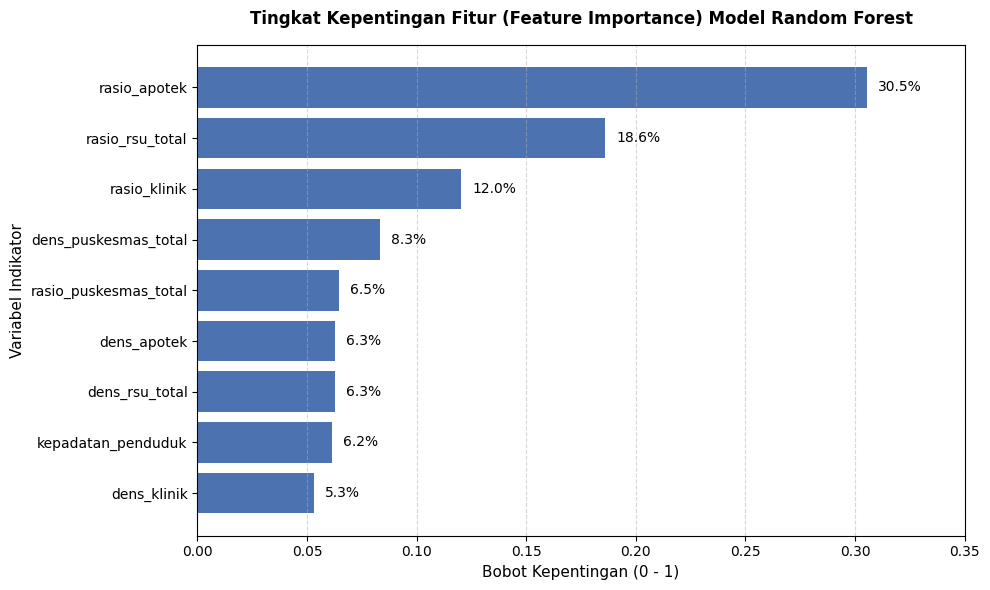

Grafik tersimpan di: C:\Users\femmy\OneDrive\Documents\6. Semester 6\tugas_akhir_machine_learning-main\outputs\figures\12_tingkat_kepentingan_fitur_important.png


In [5]:
# Load data feature importance (gunakan path relatif)
fi_path = Path('../outputs/feature_importance.csv')

# Fallback logic: Cek beberapa kemungkinan path jika file tidak ditemukan
if not fi_path.exists():
    candidates = [
        Path('../outputs/feature_importance.csv'),
        Path('outputs/feature_importance.csv'),
        Path.cwd().parent / 'outputs' / 'feature_importance.csv',
            ]
    # Pilih path pertama yang valid
    fi_path = next((p for p in candidates if p.exists()), fi_path)

if fi_path.exists():
    # Baca csv, kolom pertama sebagai index
    df_fi = pd.read_csv(fi_path, index_col=0)
    
    # Rename kolom skor
    if not df_fi.empty:
        df_fi.columns = ['Importance']
        # Urutkan dari kecil ke besar untuk barh chart
        df_fi = df_fi.sort_values('Importance', ascending=True)
        
        plt.figure(figsize=(10, 6))
        bars = plt.barh(df_fi.index, df_fi['Importance'], color='#4c72b0')
        
        plt.title('Tingkat Kepentingan Fitur (Feature Importance) Model Random Forest', fontsize=12, fontweight='bold', pad=15)
        plt.xlabel('Bobot Kepentingan (0 - 1)', fontsize=11)
        plt.ylabel('Variabel Indikator', fontsize=11)
        plt.grid(axis='x', linestyle='--', alpha=0.5)
        
        # Menambahkan angka persentase di ujung setiap batang
        for bar in bars:
            width = bar.get_width()
            plt.text(width + 0.005,
                     bar.get_y() + bar.get_height()/2,
                     f'{width:.1%}',
                     va='center', fontsize=10, color='black')
        
        plt.xlim(0, 0.35)
        plt.tight_layout()
        
        # Simpan output ke figures_dir
        figures_dir = Path('../outputs/figures')
        figures_dir.mkdir(parents=True, exist_ok=True)
        save_path = figures_dir / '12_tingkat_kepentingan_fitur_important.png'
        plt.savefig(str(save_path), dpi=200, bbox_inches='tight')
        plt.show()
        print(f'Grafik tersimpan di: {save_path.resolve()}')
    else:
        print('Data feature importance kosong.')
else:
    print(f'File tidak ditemukan: {fi_path.resolve()}')